In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path

import tempfile
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm

tqdm.pandas()

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.peint import EncodedPEINTDataset
from peint.models.modules.peint_module import PEINTModule
from evo.dataset import ComplexCherriesDataset
from evo.sequence import get_mutant
from evo.dms import get_site_by_site_consensus

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [3]:
# load the model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/logs/train/runs")
# ckpt_path = ckpt_dir / "2025-10-02_00-54-26/checkpoints/epoch_003.ckpt"
# ckpt_path = ckpt_dir / "2025-10-02_18-02-14/checkpoints/epoch_008.ckpt"
ckpt_path = ckpt_dir / "2025-10-02_23-38-10/checkpoints/last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

module = PEINTModule.load_from_checkpoint(ckpt_path).to(device)
module.eval()
vocab = module.net.vocab

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [4]:
def dataloader_from_transitions(transitions, chain_id_offset=1, batch_size=16, embed_x_per_chain=True, permute_method=None):
    datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
    with open(datafile.name, "w") as f:
        f.write("{0} transitions\n".format(len(transitions)))
        f.write("\n".join(transitions))

    _dataset = ComplexCherriesDataset(
        data_file=datafile.name,
        cache_indices = False,
        min_t = 0.0,
        quantize_t = False,
        chain_id_offset=chain_id_offset,
    )
    dataset = EncodedPEINTDataset(
        dataset=_dataset,
        vocab=vocab,
        mask_prob=0.0,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
        embed_x_per_chain=embed_x_per_chain,
        permute_chain_order=False if permute_method is None else True,
        permute_method=permute_method,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, model):
    lls = []

    for batch in tqdm(iter(dataloader), desc="Inference"):
        batch = [b.to(device) for b in batch]
        x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes = batch
        yt_mask = y_tgt != vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()    
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

    lls = np.concatenate(lls)
    return lls

In [5]:
def csp_perplexity_single(parent_aa_seq, child_aa_seq, logits, mask):
    """Calculate the CSP perplexity for a single parent and child sequence.

    CSP means "conditional substution probability" and means that we only compute
    the perplexity for the sites where the parent and child sequences differ, and we
    remove the wildtype amino acid from consideration.
    """
    subs_prob_list = []

    for parent_tok_idx, child_tok_idx, site_logits, is_diff in zip(parent_aa_seq, child_aa_seq, logits, mask):
        parent_tok_idx = parent_tok_idx.item()
        child_tok_idx = child_tok_idx.item()

        if parent_tok_idx == vocab.pad_idx or child_tok_idx == vocab.pad_idx:
            continue

        if parent_tok_idx == vocab.eos_idx or child_tok_idx == vocab.eos_idx:
            continue

        if parent_tok_idx == vocab.bos_idx or child_tok_idx == vocab.bos_idx:
            continue

        if parent_tok_idx != child_tok_idx:
            site_probs = np.exp(site_logits)
            assert np.isclose(site_probs.sum(), 1.0), "Site probs should sum to 1 before removing wt"
            site_probs[parent_tok_idx] = 0.0
            site_probs /= site_probs.sum()
            assert np.isclose(site_probs.sum(), 1.0), "Site probs should sum to 1 after removing wt"

            # Hack to choose random child token idx to sanity check
            # print(site_probs.shape, site_probs.sum())
            # valid_site_indices = np.where(site_probs > 0)[0]
            # child_tok_idx = np.random.choice(valid_site_indices)
            # raise ValueError("Hack to choose random child token idx to sanity check")

            # # get prob of wildtype, mutant, and other top 5
            # print("wt aa: ", vocab.tokens[parent_tok_idx], "mut aa: ", vocab.tokens[child_tok_idx])
            # print("wt idx: ", parent_tok_idx, "mut idx: ", child_tok_idx)
            # print("Prob of wt aa: ", site_probs[parent_tok_idx])
            # print("Prob of mut aa: ", site_probs[child_tok_idx])

            # # other than wt and mut, what are the top 5?
            # top_5_indices = np.argsort(site_probs)[-5:]
            # print("Top 5 other aa: ", [vocab.tokens[i] for i in top_5_indices if i != parent_tok_idx and i != child_tok_idx])
            # print("Top 5 other aa probs: ", [site_probs[i] for i in top_5_indices if i != parent_tok_idx and i != child_tok_idx])
            # print()

            subs_prob_list.append(site_probs[child_tok_idx])

    # print(subs_prob_list)
    
    return np.exp(-np.log(subs_prob_list).mean())

In [6]:
# load the test data that we want to infer
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data")

_dataset = ComplexCherriesDataset(
    data_file=data_dir / "dasm/edges/test/v1rodriguezCC.txt",
    cache_indices = False,
    min_t = 0.0,
    quantize_t = False,
    chain_id_offset=1,
)
dataset = EncodedPEINTDataset(
    dataset=_dataset,
    vocab=vocab,
    mask_prob=0.0,
    random_token_prob=0.0,
    leave_unmasked_prob=0.0,
    embed_x_per_chain=True,
    permute_chain_order=False,
)
dataloader = PLMRDataModule(
    dataset=dataset,
    batch_size=32,
    shuffle=False,
)._dataloader_template(dataset=dataset, training=False)

In [7]:
# run inference on the dataloader to get log likelihoods of p(y | x, t)
perplexities = []
n_batches = np.inf

for batch in tqdm(iter(dataloader), desc="Inference"):
    batch = [b.to(device) for b in batch]
    x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes = batch

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        # outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
        outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
        x_logits, y_logits = outputs["enc_logits"].detach().cpu(), outputs["dec_logits"].detach().cpu()

    # compute log likelihood at differing positions
    y_src = y_tgt.detach().cpu()
    x_src_shifted = x_src[:, 1:].detach().cpu()
    difference_mask = (x_src_shifted != y_src) & (y_src != vocab.pad_idx)
    assert difference_mask.sum(-1).all() > 0, "There should be at least one differing position per sequence"

    y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)

    # get conditional perplexities at differing positions
    for logits, parent_aa_seq, child_aa_seq, mask in zip(y_logits, x_src_shifted, y_src, difference_mask):
        perplexities.append(csp_perplexity_single(parent_aa_seq, child_aa_seq, logits, mask))

    n_batches -= 1
    if n_batches <= 0:
        break

Inference: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1058/1058 [03:02<00:00,  5.80it/s]


Median perplexity: 5.04


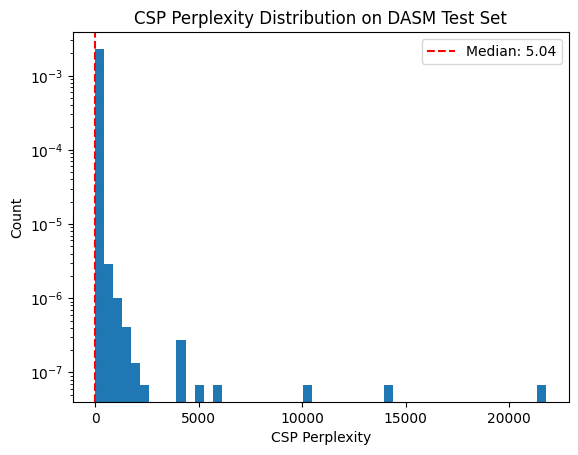

In [8]:
# histplot the perplexities
plt.hist(perplexities, bins=50, density=True)

# add xline for median of perplexities and write value
median = np.median(perplexities)
print(f"Median perplexity: {median:.2f}")
plt.axvline(median, color='r', linestyle='--', label=f'Median: {median:.2f}')
plt.legend()

plt.ylabel('Count')
plt.xlabel('CSP Perplexity')
plt.yscale('log')
plt.title("CSP Perplexity Distribution on DASM Test Set")
plt.show()

In [9]:
# save perplexities to file
perplexities = np.array(perplexities)
pcp_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed/rodriguez-igh.csv")
assert pcp_df.shape[0] == perplexities.shape[0], "Number of perplexities should match number of sequences"
pcp_df["peint_csp_perplexity"] = perplexities
pcp_df['peint_csp_perplexity'].describe()
pcp_df.to_csv("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed/rodriguez-igh.csv", index=False)

In [10]:
# Infer ppl for the koenig binding dataset
df = pd.read_csv("/scratch/users/stephen.lu/projects/protevo/data/flab/Koenig2017_g6_er.csv")

heavy_wt = get_site_by_site_consensus(df, "heavy")
light_wt = get_site_by_site_consensus(df, "light")
print(len(heavy_wt), len(light_wt), len(heavy_wt) + len(light_wt))

df['heavy_mut'] = df['heavy'].apply(lambda x: get_mutant(x, heavy_wt))
df['light_mut'] = df['light'].apply(lambda x: get_mutant(x, light_wt))
df['mut'] = df['heavy_mut'] + df['light_mut']
df.set_index('mut', inplace=True)

120 108 228


In [11]:
heavy_transitions = [ f"{heavy_wt.strip()} {row.heavy.strip()} 0.5" for _, row in df.iterrows() ]
dataloader = dataloader_from_transitions(heavy_transitions, batch_size=32, chain_id_offset=1)
heavy_lls = infer_log_likelihoods(dataloader, module)

Inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 134/134 [00:12<00:00, 10.50it/s]


In [12]:
light_transitions = [ f"{light_wt.strip()} {row.light.strip()} 0.5" for _, row in df.iterrows() ]
dataloader = dataloader_from_transitions(light_transitions, batch_size=32, chain_id_offset=2)
light_lls = infer_log_likelihoods(dataloader, module)

Inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 134/134 [00:12<00:00, 10.44it/s]


In [13]:
df['heavy_ll'] = heavy_lls
df['light_ll'] = light_lls
df['heavy_plus_light_ll'] = df['heavy_ll'] + df['light_ll']
df['heavy_plus_light_ppl'] = np.exp(-df['heavy_plus_light_ll'] / (len(heavy_wt) + len(light_wt)))

In [24]:
heavy_transitions = []
light_transitions = []
heavy_muts = []
light_muts = []

for i, row in df.iterrows():
    if row['heavy'] != heavy_wt:
        heavy_muts.append(row['heavy_mut'])
        heavy_transitions.append(f"{heavy_wt.strip()}.{light_wt.strip()} {row.heavy.strip()}.{light_wt.strip()} 0.5")
    if row['light'] != light_wt:
        light_muts.append(row['light_mut'])
        light_transitions.append(f"{heavy_wt.strip()}.{light_wt.strip()} {heavy_wt.strip()}.{row.light.strip()} 0.5")

In [25]:
heavy_fw_dataloader = dataloader_from_transitions(heavy_transitions, batch_size=32, permute_method=None)
light_fw_dataloader = dataloader_from_transitions(light_transitions, batch_size=32, permute_method=None)
heavy_bw_dataloader = dataloader_from_transitions(heavy_transitions, batch_size=32, permute_method="reverse")
light_bw_dataloader = dataloader_from_transitions(light_transitions, batch_size=32, permute_method="reverse")

heavy_fw_lls = infer_log_likelihoods(heavy_fw_dataloader, module)
light_fw_lls = infer_log_likelihoods(light_fw_dataloader, module)
heavy_bw_lls = infer_log_likelihoods(heavy_bw_dataloader, module)
light_bw_lls = infer_log_likelihoods(light_bw_dataloader, module)

Inference: 100%|████████████████████████████████████████████████████████████████████████████| 63/63 [00:10<00:00,  5.84it/s]


In [26]:
for mut, fll, bll in zip(heavy_muts, heavy_fw_lls, heavy_bw_lls):
    ll = fll + bll
    df.at[mut, 'joint_ppl'] = np.exp(-ll / (len(heavy_wt) + len(light_wt)))

for mut, fll, bll in zip(light_muts, light_fw_lls, light_bw_lls):
    ll = fll + bll
    df.at[mut, 'joint_ppl'] = np.exp(-ll / (len(heavy_wt) + len(light_wt)))

In [27]:
df

,heavy,light,fitness,heavy_mut,light_mut,heavy_ll,light_ll,heavy_plus_light_ll,heavy_plus_light_ppl,light_then_heavy_ll,joint_ppl,heavy_then_light_ll
mut,,,,,,,,,,,,
V1A,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.819679,V1A,,-64.066086,-35.846050,-99.912140,1.549932,-210.705658,2.976420,NaN
V1C,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.328397,V1C,,-71.113342,-36.369278,-107.482620,1.602260,-223.489990,3.006635,NaN
V1D,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.585834,V1D,,-67.636978,-36.680759,-104.317734,1.580172,-237.393631,2.859137,NaN
V1E,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.806183,V1E,,-67.055168,-37.779076,-104.834244,1.583756,-207.234406,3.066207,NaN
V1F,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.452152,V1F,,-64.972290,-37.785255,-102.757545,1.569396,-234.410156,3.035590,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
K106S,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.396611,,K106S,-65.854340,-39.946671,-105.801010,1.590486,NaN,2.924060,-219.285141
K106T,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.254802,,K106T,-65.611115,-39.572159,-105.183273,1.586182,NaN,3.121398,-229.139587
K106V,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.888825,,K106V,-62.383881,-40.231125,-102.615005,1.568415,NaN,3.120267,-213.679993


In [28]:
df.to_csv("/scratch/users/stephen.lu/projects/protevo/data/flab/Koenig2017_g6_peint_dasm_joint_t=0.5.csv", index=False)

In [ ]:
batch_size = 32

# get conditional ppl for mutations in the koenig dataset
heavy_dataloader = dataloader_from_transitions(heavy_transitions, batch_size=batch_size, permute_method="reverse")
light_dataloader = dataloader_from_transitions(light_transitions, batch_size=batch_size, permute_method=None)

heavy_conditional_ppls = []
light_conditional_ppls = []

for idx, batch in tqdm(enumerate(iter(heavy_dataloader)), desc="Heavy conditional ppl inference"):
    batch = [b.to(device) for b in batch]
    x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes = batch
    mut_codes = heavy_muts[idx * batch_size : (idx + 1) * batch_size]
    mut_indices = [int(mut_code[1:-1]) for mut_code in mut_codes]

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
        x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

    # get csp ppl for different positions
    y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
    y_logits = y_logits.detach().cpu()

    for logits, parent_aa_seq, child_aa_seq, mask in zip(y_logits, x_src_shifted, y_src, difference_mask):
        ppl = csp_perplexity_single(parent_aa_seq, child_aa_seq, logits, mask)
        heavy_conditional_ppls.append(ppl)

for batch in tqdm(iter(light_dataloader), desc="Light conditional ppl inference"):
    batch = [b.to(device) for b in batch]
    x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes = batch

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        outputs = module.forward(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
        x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

    # get csp ppl for different positions
    y_src = y_tgt
    x_src_shifted = x_src[:, 1:]
    difference_mask = (x_src_shifted != y_src) & (y_src != vocab.pad_idx)
    assert difference_mask.sum(-1).all() == 1, "There should be exactly one differing position per sequence"
    y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
    y_logits = y_logits.detach().cpu()
    x_src_shifted = x_src_shifted.detach().cpu()
    y_src = y_src.detach().cpu()
    difference_mask = difference_mask.detach().cpu()

    for logits, parent_aa_seq, child_aa_seq, mask in zip(y_logits, x_src_shifted, y_src, difference_mask):
        ppl = csp_perplexity_single(parent_aa_seq, child_aa_seq, logits, mask)
        light_conditional_ppls.append(ppl)

Heavy conditional ppl inference:   0%|                                                               | 0/71 [00:00<?, ?it/s]


RuntimeError: The size of tensor a (231) must match the size of tensor b (230) at non-singleton dimension 1